In [76]:
import pandas as pd
import numpy as np
import seaborn as sns

In [77]:
data = pd.read_csv('zomato.csv', encoding='latin1')

In [ ]:
data

In [43]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [ ]:
data['Restaurant ID'].unique()
# Seems useless ---> drop

In [ ]:
data['Restaurant Name'].unique()
# There are many unwanted character in names of restautant

In [ ]:
data['Country Code'].unique()
# These are categorical values , we have to encode it too

In [ ]:
for x in data['City'].unique():
    print(x)
# "City" written after name
# "/" is there for 2 names

In [ ]:
data['Address'].unique()
# Too long , seems useless ---> drop 
# City is repeated in here 

In [45]:
data['Locality'].unique()
# Too long , seems useless ---> drop 
# City is repeated in here 

<ArrowStringArray>
[      'Century City Mall, Poblacion, Makati City',
      'Little Tokyo, Legaspi Village, Makati City',
      'Edsa Shangri-La, Ortigas, Mandaluyong City',
          'SM Megamall, Ortigas, Mandaluyong City',
 'SM by the Bay, Mall of Asia Complex, Pasay City',
     'Sofitel Philippine Plaza Manila, Pasay City',
                                       'Kapitolyo',
            'UP Town Center, Diliman, Quezon City',
                                  'Addition Hills',
                                   'Little Baguio',
 ...
                                   'AsmalÛ±mescit',
                                           'Bebek',
                               'Beôiktaô Merkez',
                                     'Caddebostan',
                                        'Emirgí¢n',
                                'KadÛ±kí_y Merkez',
                                        'Karakí_y',
                                       'Koôuyolu',
                                     'Ku

In [ ]:
data['Locality Verbose'].unique()
# Too long , seems useless ---> drop 
# City is repeated in here 

<ArrowStringArray>
[      'Century City Mall, Poblacion, Makati City, Makati City',
      'Little Tokyo, Legaspi Village, Makati City, Makati City',
 'Edsa Shangri-La, Ortigas, Mandaluyong City, Mandaluyong City',
     'SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City',
  'SM by the Bay, Mall of Asia Complex, Pasay City, Pasay City',
      'Sofitel Philippine Plaza Manila, Pasay City, Pasay City',
                                        'Kapitolyo, Pasig City',
            'UP Town Center, Diliman, Quezon City, Quezon City',
                                'Addition Hills, San Juan City',
                                 'Little Baguio, San Juan City',
 ...
                                     'AsmalÛ±mescit, ÛÁstanbul',
                                             'Bebek, ÛÁstanbul',
                                 'Beôiktaô Merkez, ÛÁstanbul',
                                       'Caddebostan, ÛÁstanbul',
                                          'Emirgí¢n, ÛÁstanbul',
 

In [73]:
data['Longitude'].unique()

array([121.027535  , 121.014101  , 121.056831  , ...,  29.03464001,
        29.036019  ,  29.02601603], shape=(8120,))

In [74]:
data['Latitude'].unique()

array([14.565443  , 14.553708  , 14.581404  , ..., 41.05581715,
       41.057979  , 40.98477563], shape=(8677,))

In [ ]:
data['Cuisines'].unique()
# Multivalued

<ArrowStringArray>
[        'French, Japanese, Desserts',                           'Japanese',
   'Seafood, Asian, Filipino, Indian',                    'Japanese, Sushi',
                   'Japanese, Korean',                            'Chinese',
                    'Asian, European', 'Seafood, Filipino, Asian, European',
            'European, Asian, Indian',                           'Filipino',
 ...
       'Kebab, Turkish Pizza, Dí_ner',                      'Turkish Pizza',
     'Kebab, Desserts, Turkish Pizza',          'Restaurant Cafe, Desserts',
 'Restaurant Cafe, Turkish, Desserts',                    'Restaurant Cafe',
                   'Desserts, Bí_rek',                     'Burger, Izgara',
    'World Cuisine, Patisserie, Cafe',             'Italian, World Cuisine']
Length: 1826, dtype: str

In [ ]:
data['Average Cost for two'].unique()
# Heavy outliers

array([  1100,   1200,   4000,   1500,   1000,   2000,   6000,    800,
          900,    700,    850,    600,   3000,   1800,     55,     30,
           45,     60,     50,     80,     90,    200,    150,    100,
          230,    240,    350,    140,    170,    120,    250,     40,
           70,    300,     85,     75,    400,     65,     25,     10,
            0,     20,     35,      7,    270,    500,    430,    315,
          220,     95,    190,    260,    180,    330,    280,    160,
          285,    130,    110,   2500,   3600,    550,   1400,    450,
          950,    650,   1300,   2400,   1600,   2200,    750,   1700,
         1250,   1900,   2700,   3500,   5000,   2300,   1750,   3200,
         2100,   1850,   4500,   3300,   1350,   1650,   1950,   1050,
          290,   1450,   2800,   3650,   4800,   1550,    720,   6500,
         7000,   1150,   2900,   2600,   4700,   3700,   3800,   4100,
         4300,   2650,   5100,   5500,   4400,   4200,   8000,   2350,
      

In [ ]:
len(data[data['Average Cost for two'] > 3000])
# Only 104 values above 3000

104

In [62]:
data['Currency'].unique()
# Contain (something)
# Can be reduced to value just inside bracket

<ArrowStringArray>
[      'Botswana Pula(P)',     'Brazilian Real(R$)',              'Dollar($)',
     'Emirati Diram(AED)',     'Indian Rupees(Rs.)', 'Indonesian Rupiah(IDR)',
          'NewZealand($)',             'Pounds(£)',        'Qatari Rial(QR)',
                'Rand(R)',  'Sri Lankan Rupee(LKR)',       'Turkish Lira(TL)']
Length: 12, dtype: str

In [ ]:
data['Has Table booking'].unique()
# Can be converted to bool

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [ ]:
data['Has Online delivery'].unique()
# Can be converted to bool

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [ ]:
data['Is delivering now'].unique()
# Can be converted to bool
# May have high correlation with "Has online delivery"

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [ ]:
data['Switch to order menu'].unique()
# Contain only single value for all rows ---> drop

<ArrowStringArray>
['No']
Length: 1, dtype: str

In [ ]:
data['Price range'].unique()
# Maybe wrong value , price range 1 2 3 4 ---> drop

array([3, 4, 2, 1])

In [ ]:
data['Aggregate rating'].unique()

array([4.8, 4.5, 4.4, 4.9, 4. , 4.2, 4.3, 3.6, 4.7, 3. , 3.8, 3.7, 3.2,
       3.1, 0. , 4.1, 3.3, 4.6, 3.9, 3.4, 3.5, 2.2, 2.9, 2.4, 2.6, 2.8,
       2.1, 2.7, 2.5, 1.8, 2. , 2.3, 1.9])

In [ ]:
data['Rating color'].unique()
# categorical value , should be encoded

<ArrowStringArray>
['Dark Green', 'Green', 'Yellow', 'Orange', 'White', 'Red']
Length: 6, dtype: str

In [ ]:
data['Rating text'].unique()
# Ordered categories

<ArrowStringArray>
['Excellent', 'Very Good', 'Good', 'Average', 'Not rated', 'Poor']
Length: 6, dtype: str

In [ ]:
data['Votes'].unique()
# Idk

array([ 314,  591,  270, ...,  788, 1034,  901], shape=(1012,))

In [79]:
data.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


### Plotting

<Axes: xlabel='Aggregate rating', ylabel='Count'>

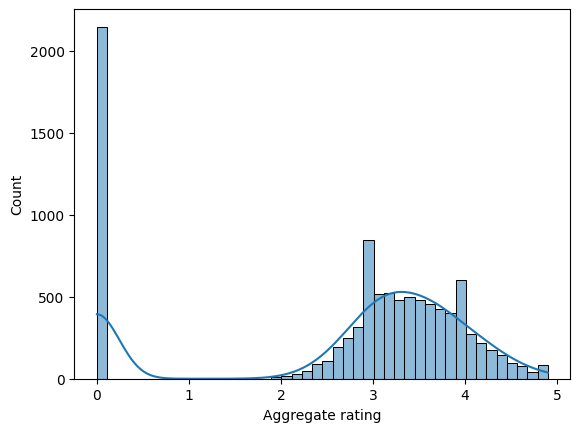

In [ ]:
sns.histplot(data['Aggregate rating'], kde=True)
# High unrated restarant , > 2000
# 2 to 4.9 normal distribution
# Overall left skewed

<Axes: xlabel='Average Cost for two', ylabel='Count'>

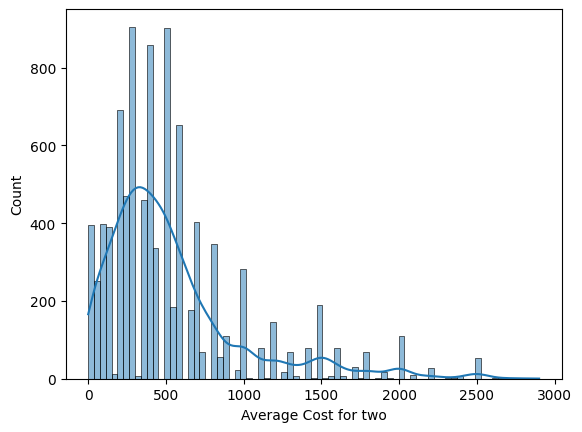

In [91]:
avgc2 = data[data['Average Cost for two'] < 3000 ]
sns.histplot(avgc2['Average Cost for two'], kde=True)
# right skewed 

<Axes: ylabel='Currency'>

C:\Users\sahil\AppData\Roaming\Python\Python311\site-packages\IPython\core\events.py:100: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\sahil\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


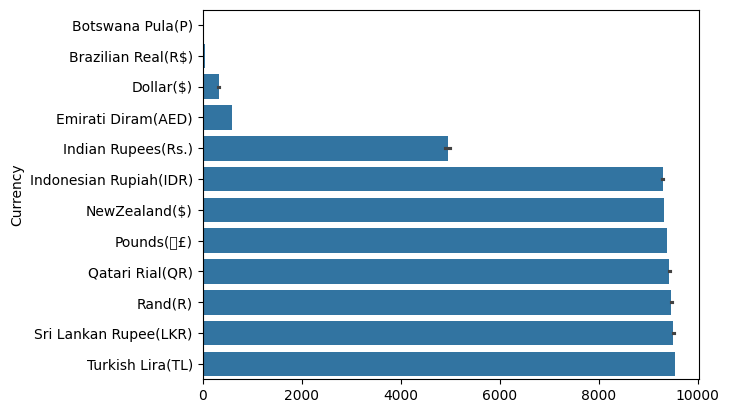

In [93]:
sns.barplot(data['Currency'])

In [ ]:
data['Currency'].value_counts()
# Buased data 

Currency
Indian Rupees(Rs.)        8652
Dollar($)                  482
Pounds(£)                  80
Brazilian Real(R$)          60
Emirati Diram(AED)          60
Rand(R)                     60
NewZealand($)               40
Turkish Lira(TL)            34
Botswana Pula(P)            22
Indonesian Rupiah(IDR)      21
Qatari Rial(QR)             20
Sri Lankan Rupee(LKR)       20
Name: count, dtype: int64

<Axes: ylabel='Is delivering now'>

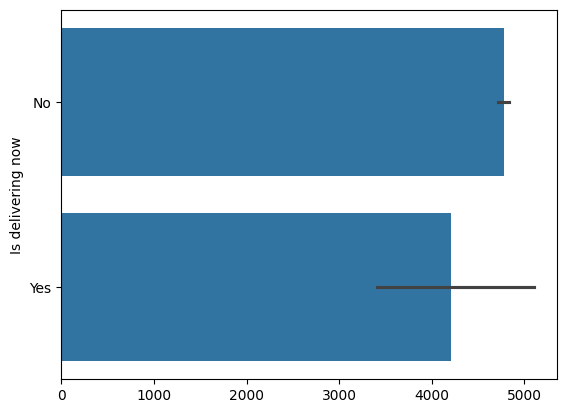

In [ ]:
sns.barplot(data['Is delivering now'])
# Little biased

<Axes: ylabel='Has Online delivery'>

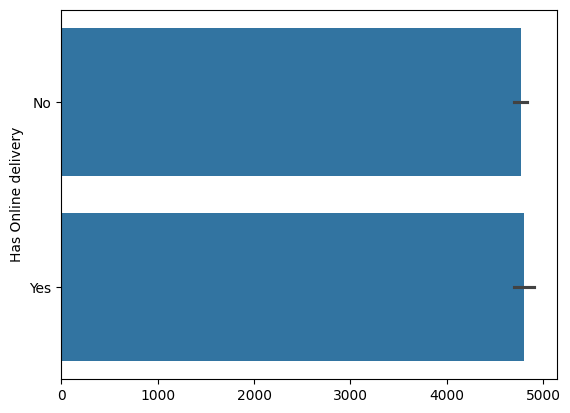

In [ ]:
sns.barplot(data['Has Online delivery'])
# Equally distributed

<Axes: ylabel='Has Table booking'>

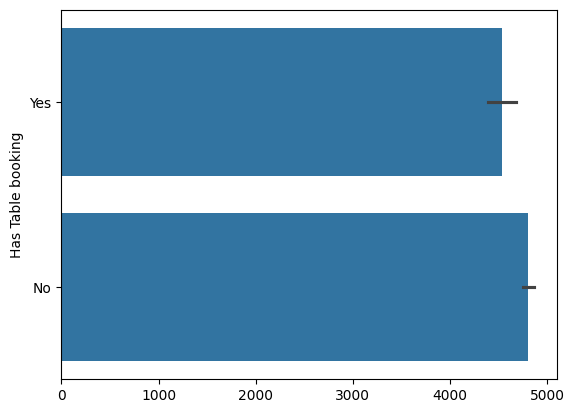

In [ ]:
sns.barplot(data['Has Table booking'])
# Almost equally distributed